In [2]:
import sys
sys.path.append(".")

from utils import load_prices, compute_returns, build_network
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

print("Ready")

Ready


In [14]:
results = pd.read_csv("data/results.csv", index_col=0, parse_dates=True)

# Download S&P 500
sp500_prices = yf.download("^GSPC", start="2019-01-01", end="2024-12-31", auto_adjust=True)
sp500_prices = sp500_prices.xs("Close", axis=1, level="Price")
sp500_returns = np.log(sp500_prices / sp500_prices.shift(1)).dropna()
# sp500_returns.index = sp500_returns.index.tz_localize(None)
# # Align weekly returns to results.index
sp500_weekly = []

# for date in results.index:
#     date_idx = sp500_returns.index.get_loc(date)
#     if date_idx + 5 > len(sp500_returns):
#         break
#     week = sp500_returns.iloc[date_idx : date_idx + 5]
#     sp500_weekly.append(week.values.sum())


for date in results.index:
    # find nearest available date in sp500_returns
    pos = sp500_returns.index.searchsorted(date)
    if pos + 5 > len(sp500_returns):
        break
    week = sp500_returns.iloc[pos : pos + 5]
    sp500_weekly.append(week.values.sum())
sp500_weekly = pd.Series(sp500_weekly, index=results.index[:len(sp500_weekly)])

print(f"Aligned {len(sp500_weekly)} weekly S&P 500 returns")
print(f"Mean weekly return: {sp500_weekly.mean():.4f}")
print(f"Std weekly return:  {sp500_weekly.std():.4f}")

[*********************100%***********************]  1 of 1 completed

Aligned 425 weekly S&P 500 returns
Mean weekly return: 0.0025
Std weekly return:  0.0255


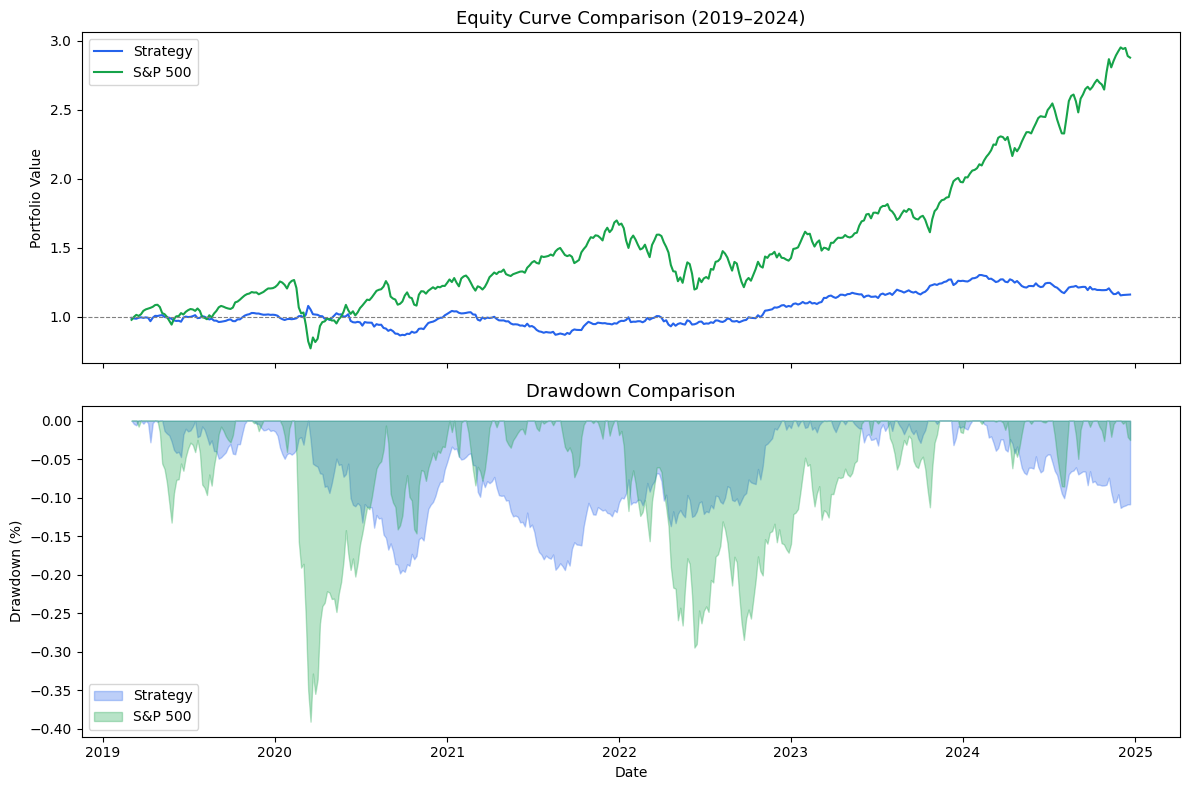

Metric                           Strategy         S&P 500
Mean weekly return        0.0004 (1.8% ann.) 0.0025 (12.9% ann.)
Weekly volatility         0.0119 (8.6% ann.) 0.0255 (18.4% ann.)
Annualized Sharpe                   0.213           0.704
Max drawdown                       -19.8%          -39.1%
Total return                        16.1%          187.7%


In [17]:
# --- Metrics ---
def compute_metrics(weekly_returns):
    equity_curve = np.exp(weekly_returns.cumsum())
    mean = weekly_returns.mean()
    std  = weekly_returns.std()
    sharpe = (mean / std) * np.sqrt(52)
    rolling_max  = equity_curve.cummax()
    drawdown     = (equity_curve - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    total_return = equity_curve.iloc[-1] - 1
    return equity_curve, drawdown, {
        "Mean weekly return": f"{mean:.4f} ({mean*52*100:.1f}% ann.)",
        "Weekly volatility":  f"{std:.4f} ({std*np.sqrt(52)*100:.1f}% ann.)",
        "Annualized Sharpe":  f"{sharpe:.3f}",
        "Max drawdown":       f"{max_drawdown*100:.1f}%",
        "Total return":       f"{total_return*100:.1f}%"
    }

strategy_curve, strategy_dd, strategy_metrics = compute_metrics(results["strategy"])
sp500_curve,    sp500_dd,    sp500_metrics    = compute_metrics(sp500_weekly)

# --- Equity Curve Comparison ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(strategy_curve.index, strategy_curve.values, color="#2563eb", linewidth=1.5, label="Strategy")
axes[0].plot(sp500_curve.index,    sp500_curve.values,    color="#16a34a", linewidth=1.5, label="S&P 500")
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("Equity Curve Comparison (2019–2024)", fontsize=13)
axes[0].set_ylabel("Portfolio Value")
axes[0].legend()

axes[1].fill_between(strategy_dd.index, strategy_dd.values, 0, color="#2563eb", alpha=0.3, label="Strategy")
axes[1].fill_between(sp500_dd.index,    sp500_dd.values,    0, color="#16a34a", alpha=0.3, label="S&P 500")
axes[1].set_title("Drawdown Comparison", fontsize=13)
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig("benchmark_comparison.png", dpi=150)
plt.show()

# --- Summary Table ---
print(f"{'Metric':<25} {'Strategy':>15} {'S&P 500':>15}")
print("=" * 55)
for key in strategy_metrics:
    print(f"{key:<25} {strategy_metrics[key]:>15} {sp500_metrics[key]:>15}")

-   Return: The S&P crushed the strategy — 187.7% vs 16.1% over 6 years. 
-   Sharpe: S&P at 0.704 vs strategy at 0.213. The S&P delivers better return per unit of risk. The strategy doesn't compensate enough for the risk it takes.
-   Max drawdown: This is where the strategy differs — -19.8% vs -39.1%. That -39% on the S&P is the COVID crash of March 2020, visible clearly on the chart. 

The strategy is not trying to beat the S&P on returns — it was never designed to. It's a market-neutral long/short strategy, meaning it doesn't depend on the market going up to make money. The fact that it has roughly half the drawdown of the S&P during a crisis is exactly the behavior we want from this type of strategy. A portfolio manager would combine it with long-only exposure, not use it standalone.